In [20]:
# imports
# ----------------------
# Data 
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns


# model stuff 
from sklearn.preprocessing import StandardScaler

In [4]:
df = pd.read_csv('Credit_Card_Applications.csv')
df.head()

,CustomerID,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,Class
0,15776156,1,22.08,11.46,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,15739548,0,22.67,7.00,2,8,4,0.165,0,0,0,0,2,160,1,0
2,15662854,0,29.58,1.75,1,4,4,1.250,0,0,0,1,2,280,1,0
3,15687688,0,21.67,11.50,1,5,3,0.000,1,1,11,1,2,0,1,1
4,15715750,1,20.17,8.17,2,6,4,1.960,1,1,14,0,2,60,159,1


In [5]:
df.info()
# no missing/null values at all 
# df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  690 non-null    int64  
 1   A1          690 non-null    int64  
 2   A2          690 non-null    float64
 3   A3          690 non-null    float64
 4   A4          690 non-null    int64  
 5   A5          690 non-null    int64  
 6   A6          690 non-null    int64  
 7   A7          690 non-null    float64
 8   A8          690 non-null    int64  
 9   A9          690 non-null    int64  
 10  A10         690 non-null    int64  
 11  A11         690 non-null    int64  
 12  A12         690 non-null    int64  
 13  A13         690 non-null    int64  
 14  A14         690 non-null    int64  
 15  Class       690 non-null    int64  
dtypes: float64(3), int64(13)
memory usage: 86.4 KB


In [6]:
df.nunique()

CustomerID    690
A1              2
A2            350
A3            215
A4              3
A5             14
A6              8
A7            132
A8              2
A9              2
A10            23
A11             2
A12             3
A13           171
A14           240
Class           2
dtype: int64

In [7]:
print(df.shape)
print(df.columns)

(690, 16)
Index(['CustomerID', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9',
       'A10', 'A11', 'A12', 'A13', 'A14', 'Class'],
      dtype='str')


In [8]:
df.duplicated().sum()
# no dups 

np.int64(0)

In [9]:
df['Class'].value_counts(normalize=True)

Class
0    0.555072
1    0.444928
Name: proportion, dtype: float64

In [10]:
df.drop(columns=["CustomerID"], inplace=True)

In [11]:
# EDA 

df.describe()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,Class
count,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.00000,690.000000,690.000000,690.000000,690.000000,690.000000
mean,0.678261,31.568203,4.758725,1.766667,7.372464,4.692754,2.223406,0.523188,0.427536,2.40000,0.457971,1.928986,184.014493,1018.385507,0.444928
std,0.467482,11.853273,4.978163,0.430063,3.683265,1.992316,3.346513,0.499824,0.495080,4.86294,0.498592,0.298813,172.159274,5210.102598,0.497318
min,0.000000,13.750000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,0.000000,22.670000,1.000000,2.000000,4.000000,4.000000,0.165000,0.000000,0.000000,0.00000,0.000000,2.000000,80.000000,1.000000,0.000000
50%,1.000000,28.625000,2.750000,2.000000,8.000000,4.000000,1.000000,1.000000,0.000000,0.00000,0.000000,2.000000,160.000000,6.000000,0.000000
75%,1.000000,37.707500,7.207500,2.000000,10.000000,5.000000,2.625000,1.000000,1.000000,3.00000,1.000000,2.000000,272.000000,396.500000,1.000000
max,1.000000,80.250000,28.000000,3.000000,14.000000,9.000000,28.500000,1.000000,1.000000,67.00000,1.000000,3.000000,2000.000000,100001.000000,1.000000


In [12]:
# using info from df.describe() and df.nunique(), we can categorize the columns into categorical and continuous features.
categorical_cols = [
    'A1',
    'A4',
    'A5',
    'A6',
    'A8',
    'A9',
    'A10',
    'A11',
    'A12'
]

continuous_cols = [
    'A2',
    'A3',
    'A7',
    'A13',
    'A14'
]

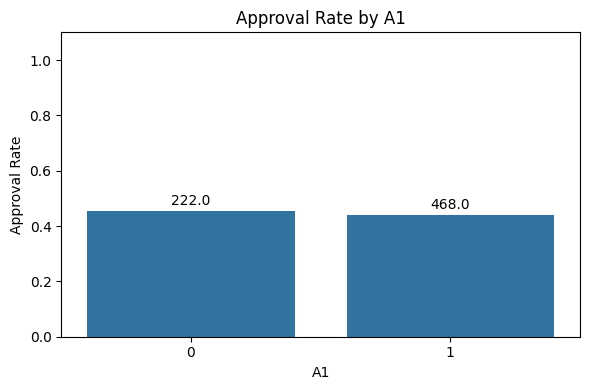

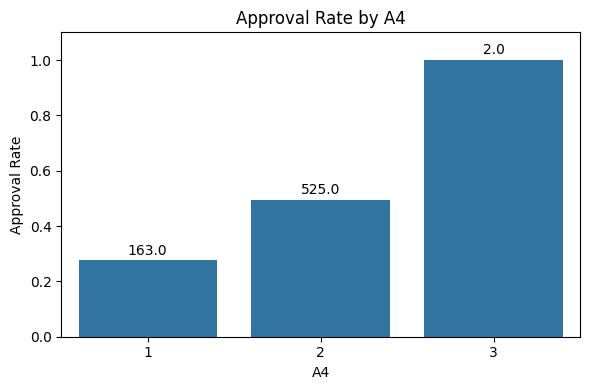

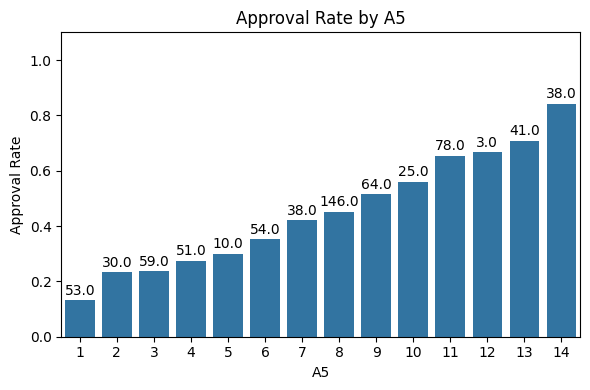

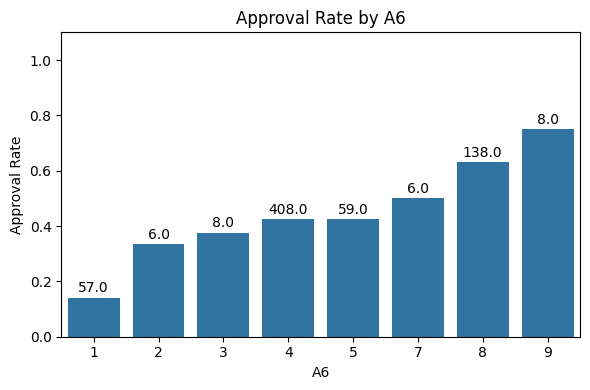

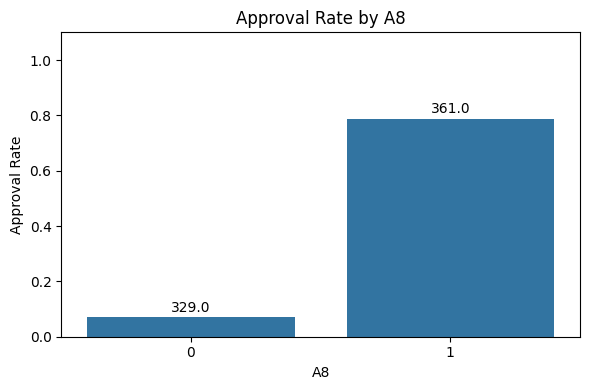

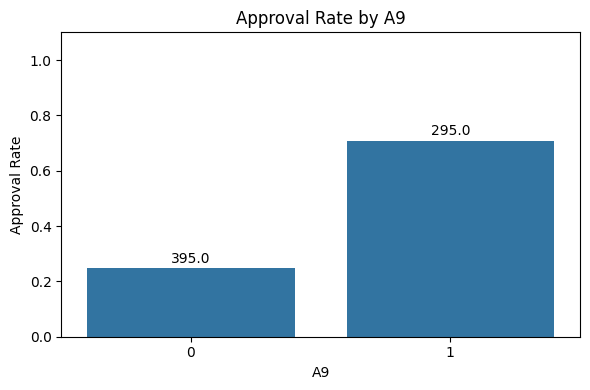

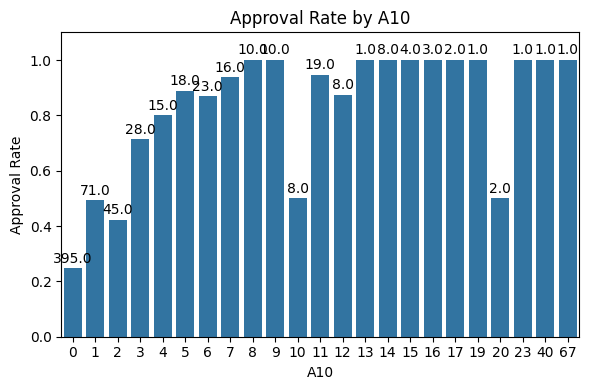

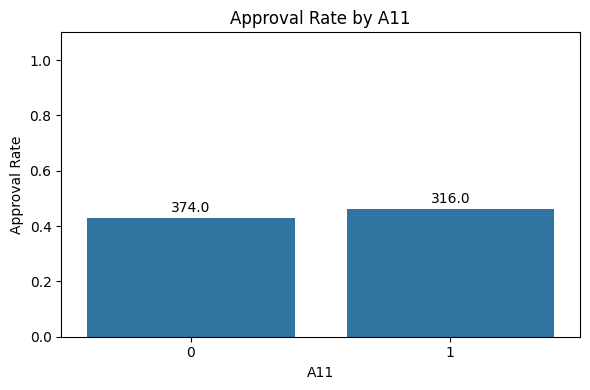

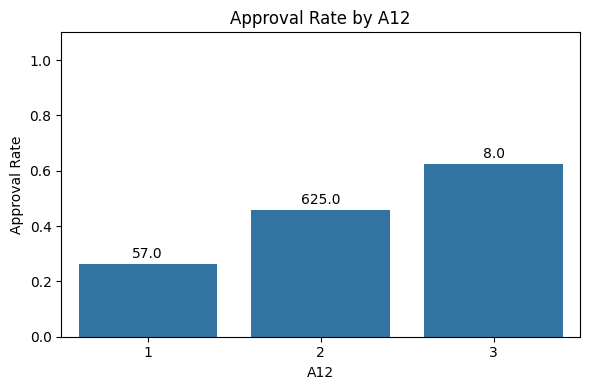

In [13]:
for col in categorical_cols:
    
    summary = (
        df.groupby(col)['Class']
        .agg(['mean', 'count'])
        .reset_index()
    )

    plt.figure(figsize=(6, 4))

    ax = sns.barplot(
        data=summary,
        x=col,
        y='mean'
    )

    # add count labels on bars
    for i, row in summary.iterrows():
        ax.text(
            i,
            row['mean'] + 0.02,
            f"{row['count']}",
            ha='center'
        )

    plt.title(f'Approval Rate by {col}')
    plt.ylabel('Approval Rate')
    plt.ylim(0, 1.1)

    plt.tight_layout()
    plt.show()

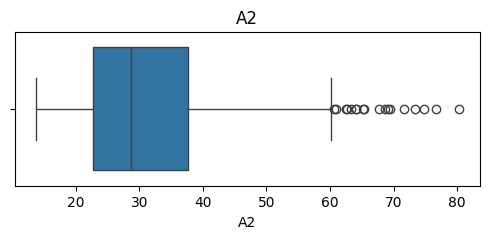

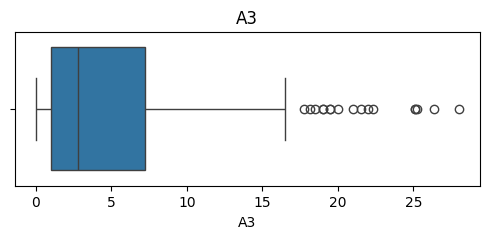

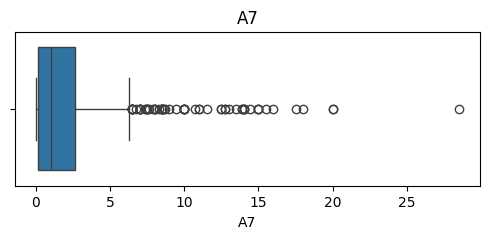

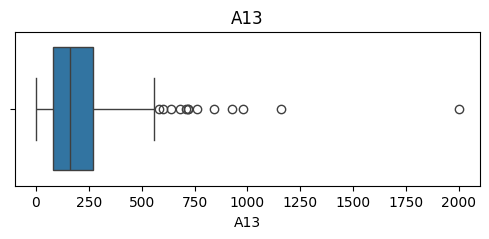

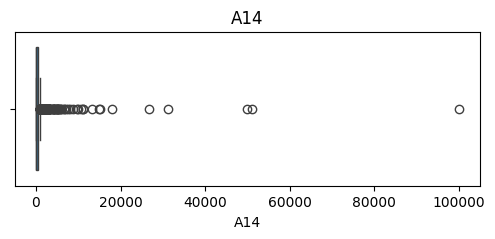

In [14]:

import seaborn as sns
import matplotlib.pyplot as plt

for col in continuous_cols:
    plt.figure(figsize=(6, 2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [ ]:
# removing outliers using 95th percentile as upper bound
df_no_outliers = df.copy()

rows_before = df_no_outliers.shape[0]

for col in continuous_cols:

    upper_bound = df_no_outliers[col].quantile(0.95)

    df_no_outliers = df_no_outliers[
        df_no_outliers[col] <= upper_bound
    ]

rows_after = df_no_outliers.shape[0]

rows_removed = rows_before - rows_after

print(f"Outliers removed: {rows_removed}")
print(f"Percent removed: {(rows_removed / rows_before) * 100:.2f}%")

Outliers removed: 155
Percent removed: 22.46%


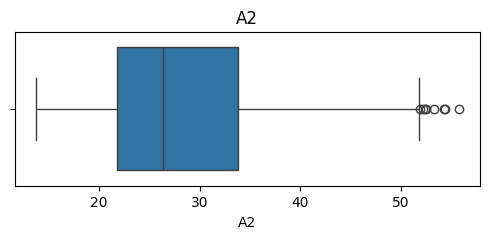

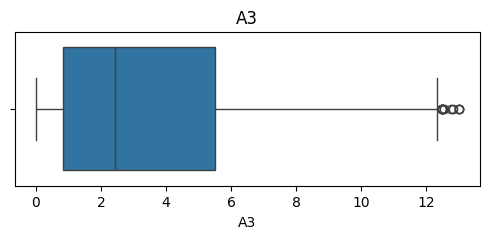

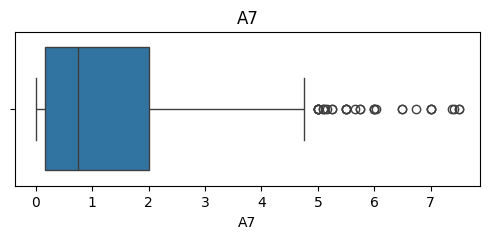

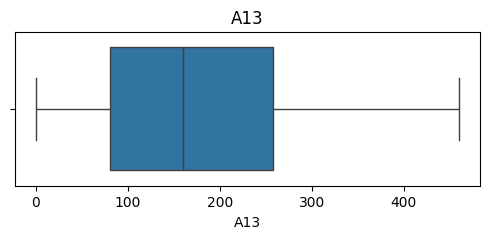

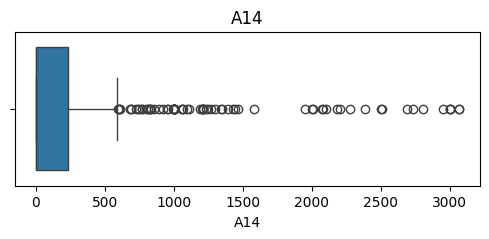

In [17]:

import seaborn as sns
import matplotlib.pyplot as plt

for col in continuous_cols:
    plt.figure(figsize=(6, 2))
    sns.boxplot(x=df_no_outliers[col])
    plt.title(col)
    plt.show()

In [ ]:
# df = df_no_outliers.copy()

In [21]:
from sklearn.preprocessing import StandardScaler

X = df_no_outliers.copy()

scaler = StandardScaler()

X[continuous_cols] = scaler.fit_transform(
    X[continuous_cols]
)